# 02 - Pretraitement et Analyse Exploratoire (EDA)

**Objectif** : Nettoyer les donnees et realiser une EDA complete avec visualisations

In [152]:
# Imports et session Spark
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler, MinMaxScaler
from pyspark.ml import Pipeline

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

spark = SparkSession.builder \
    .appName("BRFSS_Preprocessing") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

print("Spark pret")

Spark pret


26/05/28 23:04:37 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [153]:
# Charger les donnees sauvegardees depuis le notebook 01
df_spark = spark.read.parquet("/kaggle/working/brfss_selected.parquet").cache()
row_count = df_spark.count()
col_count = len(df_spark.columns)
print(f"{row_count:,} lignes x {col_count} colonnes chargees")
df_spark.show(5)

26/05/28 23:04:37 WARN CacheManager: Asked to cache already cached data.


2,176,776 lignes x 14 colonnes chargees
+--------------------+-----+------+------+--------+------------+-------+--------+--------+--------+---+----+---------+-----------------+
|HeartDiseaseorAttack|  BMI|Smoker|Stroke|Diabetes|PhysActivity|GenHlth|MentHlth|PhysHlth|DiffWalk|Sex| Age|Education|HvyAlcoholConsump|
+--------------------+-----+------+------+--------+------------+-------+--------+--------+--------+---+----+---------+-----------------+
|                 0.0|25.14|   1.0|   0.0|     0.0|         0.0|    3.0|     0.0|     0.0|     0.0|0.0| 4.0|      4.0|              0.0|
|                 0.0|29.29|   1.0|   0.0|     0.0|         0.0|    1.0|     0.0|     0.0|     0.0|0.0|13.0|      5.0|              0.0|
|                 0.0|22.76|   0.0|   0.0|     0.0|         1.0|    3.0|     0.0|     2.0|     0.0|1.0|10.0|      6.0|              0.0|
|                 0.0| NULL|   0.0|   0.0|     0.0|         1.0|    2.0|     7.0|     0.0|     0.0|1.0| 1.0|      5.0|             NULL|
|

In [154]:
# Verifier les valeurs manquantes
print("Valeurs manquantes par colonne :")
null_counts = df_spark.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_spark.columns
])
null_counts.show(truncate=False)

# Version Pandas pour meilleur affichage
total_rows = row_count if "row_count" in globals() else df_spark.count()
null_df = null_counts.toPandas().T
null_df.columns = ['null_count']
null_df['null_pct'] = (null_df['null_count'] / total_rows * 100).round(2)
print(null_df[null_df['null_count'] > 0])

Valeurs manquantes par colonne :
+--------------------+------+------+------+--------+------------+-------+--------+--------+--------+---+-----+---------+-----------------+
|HeartDiseaseorAttack|BMI   |Smoker|Stroke|Diabetes|PhysActivity|GenHlth|MentHlth|PhysHlth|DiffWalk|Sex|Age  |Education|HvyAlcoholConsump|
+--------------------+------+------+------+--------+------------+-------+--------+--------+--------+---+-----+---------+-----------------+
|23018               |220598|134134|7098  |4904    |5269        |5892   |41177   |50964   |98903   |0  |43032|11436    |1160730          |
+--------------------+------+------+------+--------+------------+-------+--------+--------+--------+---+-----+---------+-----------------+

                      null_count  null_pct
HeartDiseaseorAttack       23018      1.06
BMI                       220598     10.13
Smoker                    134134      6.16
Stroke                      7098      0.33
Diabetes                    4904      0.23
PhysActivity 

In [155]:
# Suppression des doublons
count_before = df_spark.count()
df_spark = df_spark.dropDuplicates()
count_after = df_spark.count()
print(f"Doublons supprimes : {count_before - count_after:,}")
print(f"Lignes restantes : {count_after:,}")

Doublons supprimes : 416,535
Lignes restantes : 1,760,241


In [156]:
# Imputation des valeurs manquantes
# Les donnees ont deja ete binarisees dans le notebook 01 :
# - HeartDiseaseorAttack, Stroke, Diabetes, PhysActivity, Smoker, DiffWalk, Sex = 0/1
# - MentHlth, PhysHlth : 0-30 jours, 88=0
# - Age : 1-13, Education : 1-6, GenHlth : 1-5
# - BMI : valeurs reelles 10-99 kg/m²

# Types de colonnes (post-binarisation notebook 01)
continuous_cols = [c for c in ['BMI', 'MentHlth', 'PhysHlth'] if c in df_spark.columns]
binary_cols     = [c for c in [
    'HeartDiseaseorAttack', 'HighBP', 'HighChol', 'Smoker', 'Stroke',
    'PhysActivity', 'DiffWalk', 'Sex', 'HvyAlcoholConsump', 'NoDocbcCost'
] if c in df_spark.columns]
ordinal_cols    = [c for c in ['Diabetes', 'GenHlth', 'Age', 'Education', 'Income'] if c in df_spark.columns]

# Filet de securite : valeurs hors plage → null
expected_ranges = {
    "BMI":       (10.0, 99.0),
    "MentHlth":  (0.0,  30.0),
    "PhysHlth":  (0.0,  30.0),
    "Age":       (1.0,  13.0),
    "GenHlth":   (1.0,   5.0),
    "Education": (1.0,   6.0),
    "Income":    (1.0,   8.0),
}
for c, (lo, hi) in expected_ranges.items():
    if c in df_spark.columns:
        df_spark = df_spark.withColumn(
            c, F.when(F.col(c).between(lo, hi), F.col(c)).otherwise(None)
        )

df_spark = df_spark.cache()

# Imputation : mediane pour les variables continues
for col_name in continuous_cols:
    median_val = df_spark.select(F.percentile_approx(col_name, 0.5)).first()[0]
    if median_val is not None:
        df_spark = df_spark.fillna({col_name: median_val})
        print(f"  {col_name} : mediane = {median_val}")
    else:
        print(f"  {col_name} : toutes valeurs nulles — saut imputation")

# Imputation : mode pour les variables binaires et ordinales
for col_name in binary_cols + ordinal_cols:
    mode_row = (df_spark
                .where(F.col(col_name).isNotNull())
                .groupBy(col_name).count()
                .orderBy(F.desc("count"))
                .first())
    if mode_row is not None and mode_row[0] is not None:
        df_spark = df_spark.fillna({col_name: mode_row[0]})
        print(f"  {col_name} : mode = {mode_row[0]}")
    else:
        print(f"  {col_name} : mode introuvable — saut imputation")

print("\nImputation terminee")

26/05/28 23:04:43 WARN CacheManager: Asked to cache already cached data.


  BMI : mediane = 27.71
  MentHlth : mediane = 0.0
  PhysHlth : mediane = 0.0
  HeartDiseaseorAttack : mode = 0.0
  Smoker : mode = 0.0
  Stroke : mode = 0.0
  PhysActivity : mode = 1.0
  DiffWalk : mode = 0.0
  Sex : mode = 1.0
  HvyAlcoholConsump : mode = 0.0
  Diabetes : mode = 0.0
  GenHlth : mode = 3.0
  Age : mode = 10.0
  Education : mode = 6.0

Imputation terminee


In [157]:
# Validation post-imputation : coherence des donnees

print("=" * 55)
print("VALIDATION POST-IMPUTATION")
print("=" * 55)

total_rows = df_spark.count()
print(f"\nFormes : {total_rows:,} lignes x {len(df_spark.columns)} colonnes")

# 1. Valeurs nulles restantes
null_check = df_spark.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_spark.columns
])
null_df = null_check.toPandas().T
null_df.columns = ['nulls_restants']
leftover = null_df[null_df['nulls_restants'] > 0]
print("\nValeurs nulles restantes :")
if leftover.empty:
    print("  Aucune valeur nulle restante")
else:
    print(leftover.to_string())

# 2. Prevalence de la variable cible
print("\nDistribution HeartDiseaseorAttack :")
(df_spark.groupBy("HeartDiseaseorAttack")
    .count()
    .withColumn("pct", F.round(F.col("count") / F.lit(total_rows) * 100, 2))
    .orderBy("HeartDiseaseorAttack")
    .show())

# 3. Plages de valeurs des colonnes cles (sur un echantillon rapide)
check_cols = [c for c in [
    'HeartDiseaseorAttack', 'BMI', 'Smoker', 'Stroke', 'Diabetes',
    'DiffWalk', 'Sex', 'GenHlth', 'Age', 'Education'
] if c in df_spark.columns]
print("Statistiques des colonnes cles :")
df_spark.select(check_cols).describe().show()

# 4. Valeurs distinctes pour les binaires (doivent etre uniquement 0.0 et 1.0)
print("Valeurs distinctes des colonnes binaires :")
for col_name in binary_cols:
    vals = sorted([r[0] for r in df_spark.select(col_name).distinct().collect() if r[0] is not None])
    print(f"  {col_name} : {vals}")

VALIDATION POST-IMPUTATION

Formes : 1,760,241 lignes x 14 colonnes

Valeurs nulles restantes :
  Aucune valeur nulle restante

Distribution HeartDiseaseorAttack :
+--------------------+-------+-----+
|HeartDiseaseorAttack|  count|  pct|
+--------------------+-------+-----+
|                 0.0|1578647|89.68|
|                 1.0| 181594|10.32|
+--------------------+-------+-----+

Statistiques des colonnes cles :


+-------+--------------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|summary|HeartDiseaseorAttack|               BMI|             Smoker|             Stroke|           Diabetes|          DiffWalk|               Sex|           GenHlth|               Age|         Education|
+-------+--------------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+------------------+------------------+------------------+
|  count|             1760241|           1760241|            1760241|            1760241|            1760241|           1760241|           1760241|           1760241|           1760241|           1760241|
|   mean| 0.10316428261811877|28.766237657227492|0.40885992315824937|0.05119299005079418|0.15984913429467898|0.1839185656964018|0.5305483737738185| 2.689500471810394| 7.65700037665

In [158]:
# Conversion Spark -> Pandas pour les visualisations
df_pd = df_spark.toPandas()
print(f"DataFrame Pandas : {df_pd.shape}")
df_pd.info()

DataFrame Pandas : (1760241, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1760241 entries, 0 to 1760240
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   HeartDiseaseorAttack  float64
 1   BMI                   float64
 2   Smoker                float64
 3   Stroke                float64
 4   Diabetes              float64
 5   PhysActivity          float64
 6   GenHlth               float64
 7   MentHlth              float64
 8   PhysHlth              float64
 9   DiffWalk              float64
 10  Sex                   float64
 11  Age                   float64
 12  Education             float64
 13  HvyAlcoholConsump     float64
dtypes: float64(14)
memory usage: 188.0 MB


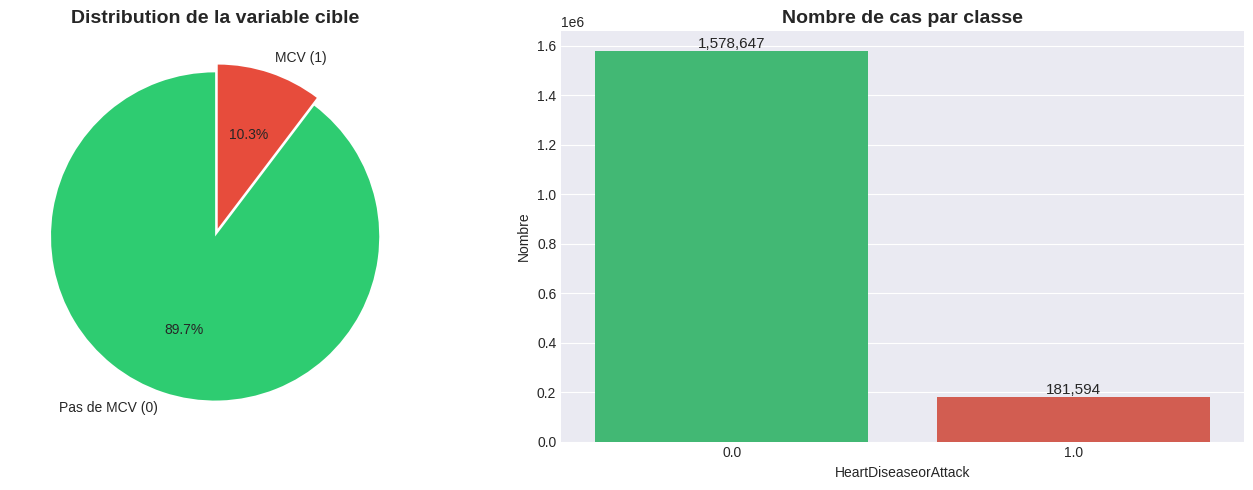

Figure sauvegardee : target_distribution.png


In [159]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
counts = df_pd['HeartDiseaseorAttack'].value_counts()
labels = ['Pas de MCV (0)', 'MCV (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, explode=(0, 0.05))
axes[0].set_title('Distribution de la variable cible', fontsize=14, fontweight='bold')

# Bar chart
sns.countplot(data=df_pd, x='HeartDiseaseorAttack', palette=colors, ax=axes[1])
axes[1].set_title('Nombre de cas par classe', fontsize=14, fontweight='bold')
axes[1].set_xlabel('HeartDiseaseorAttack')
axes[1].set_ylabel('Nombre')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : target_distribution.png')

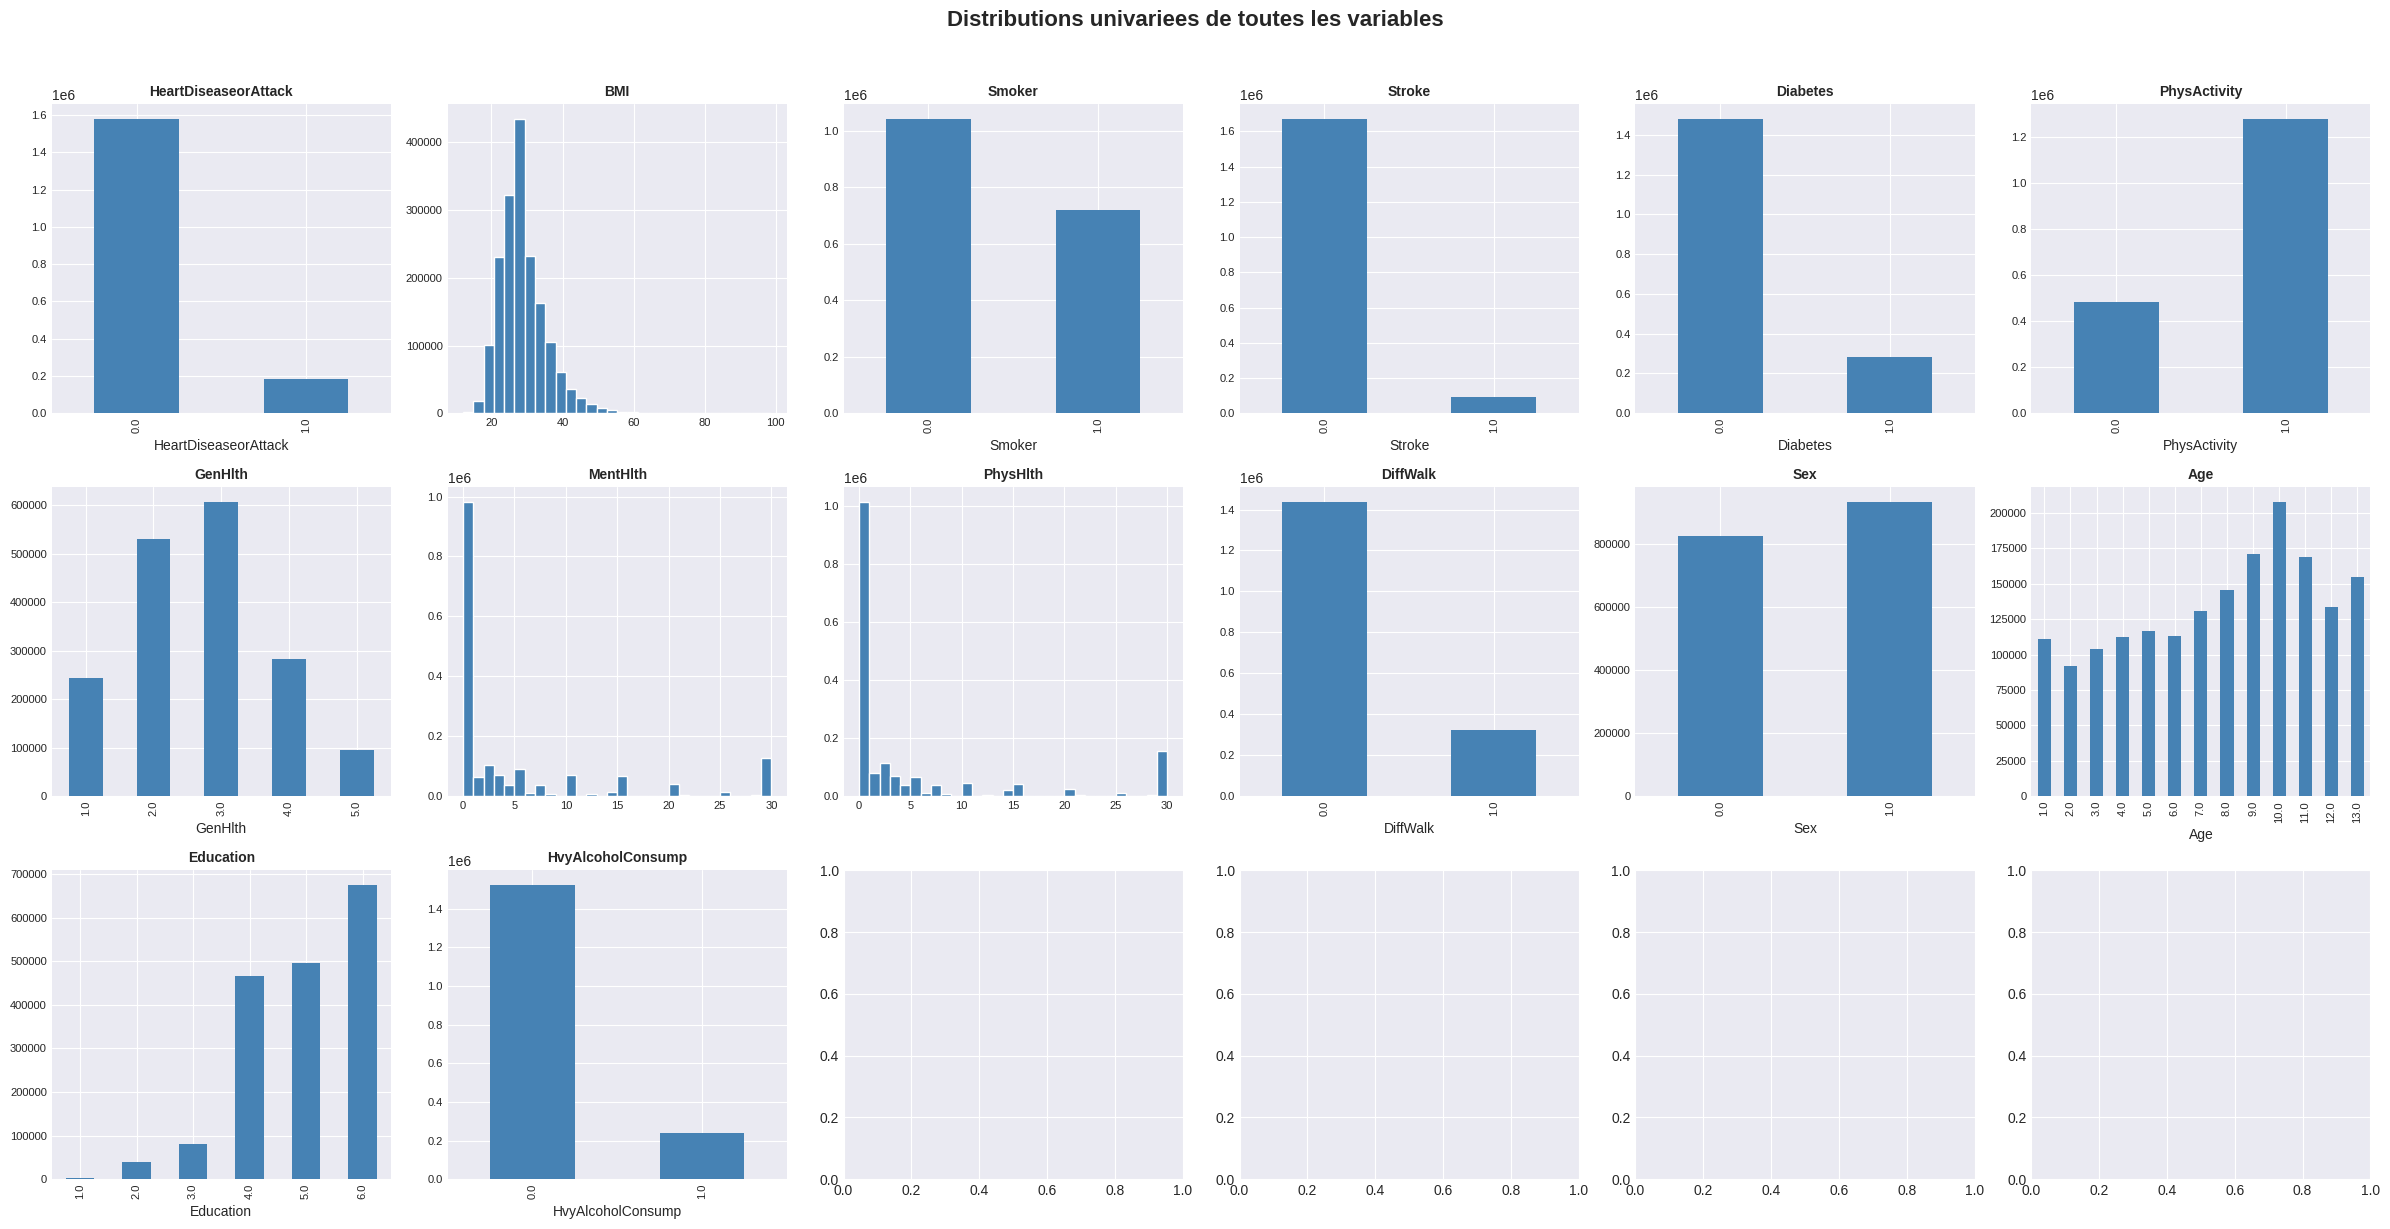

Figure sauvegardee : univariate_distributions.png


In [160]:
# Distributions univariees
fig, axes = plt.subplots(3, 6, figsize=(24, 12))
axes = axes.flatten()

for i, col in enumerate(df_pd.columns):
    if i >= 18:
        break
    if col in continuous_cols:
        df_pd[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='white')
    else:
        df_pd[col].value_counts().sort_index().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

plt.suptitle('Distributions univariees de toutes les variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/univariate_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : univariate_distributions.png')

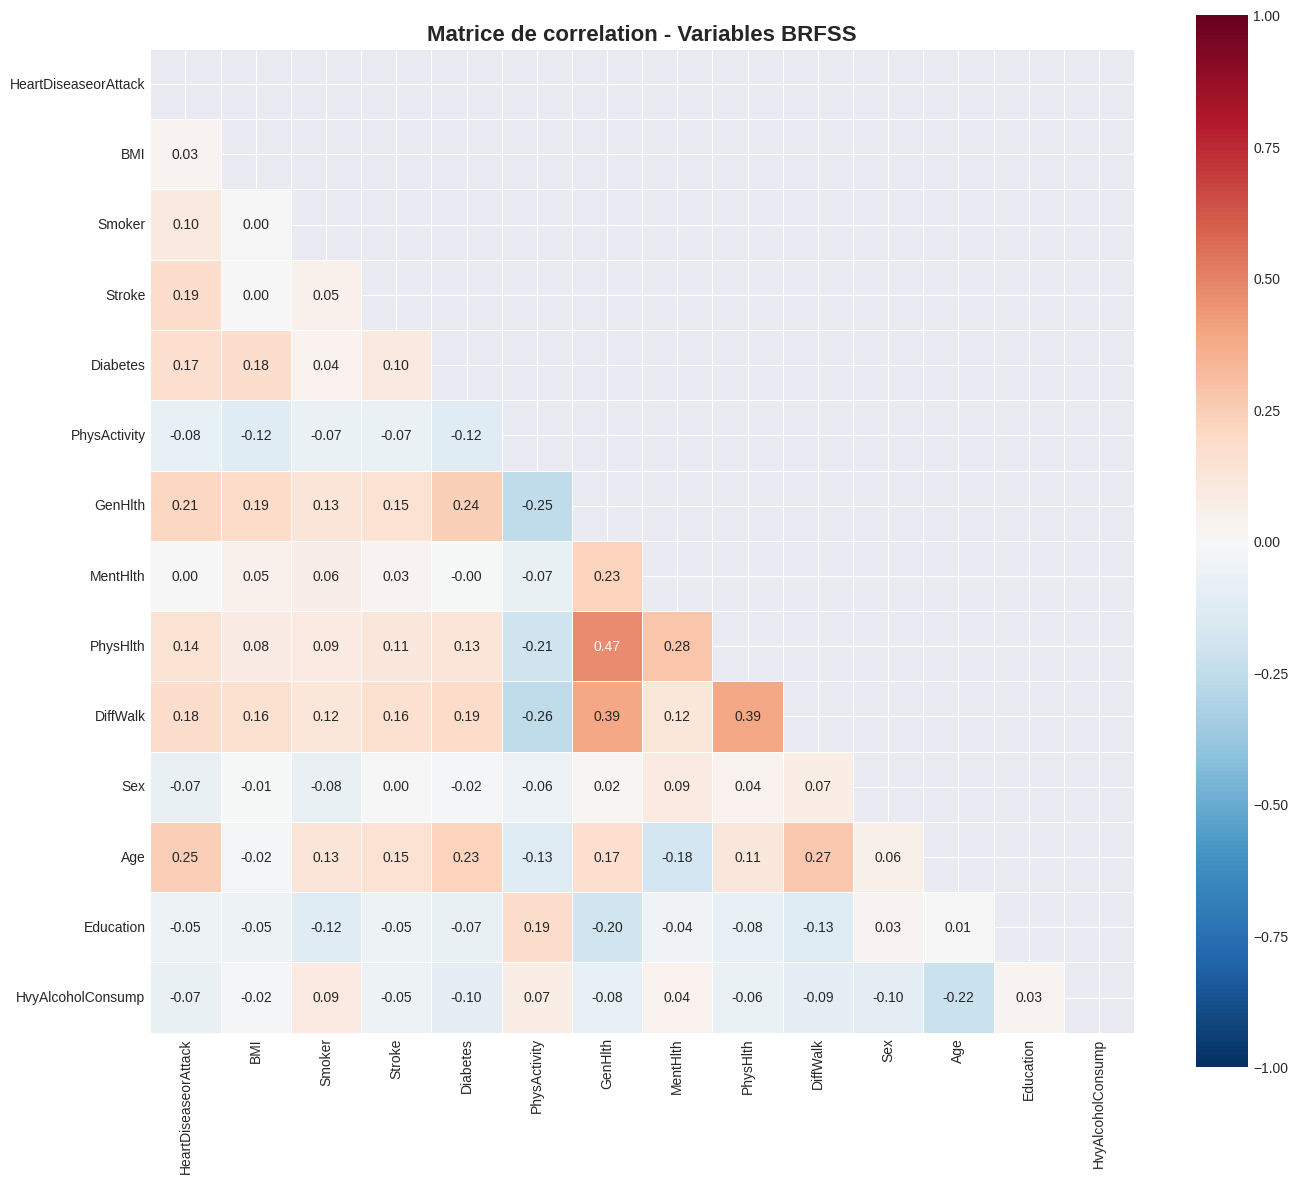

Figure sauvegardee : correlation_heatmap.png


In [161]:
# Heatmap de correlation
plt.figure(figsize=(14, 12))
corr_matrix = df_pd.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title('Matrice de correlation - Variables BRFSS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : correlation_heatmap.png')

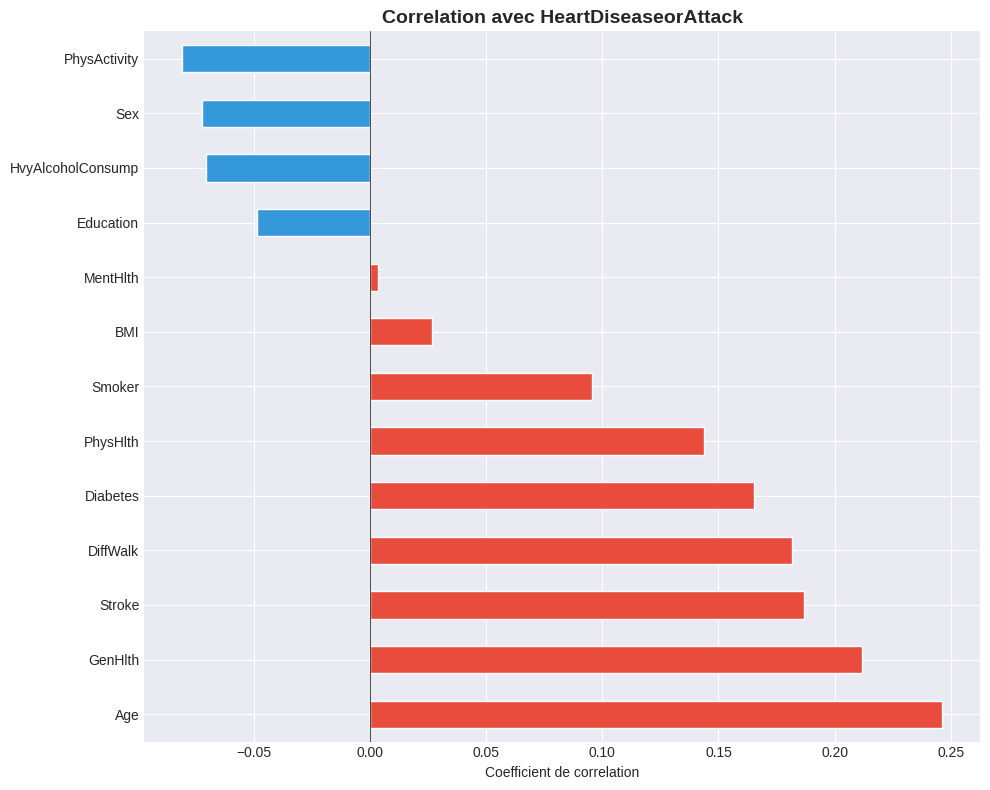

In [162]:
# Correlation de chaque variable avec HeartDiseaseorAttack
target_corr = corr_matrix['HeartDiseaseorAttack'].drop('HeartDiseaseorAttack').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Correlation avec HeartDiseaseorAttack', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient de correlation')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('/kaggle/working/target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

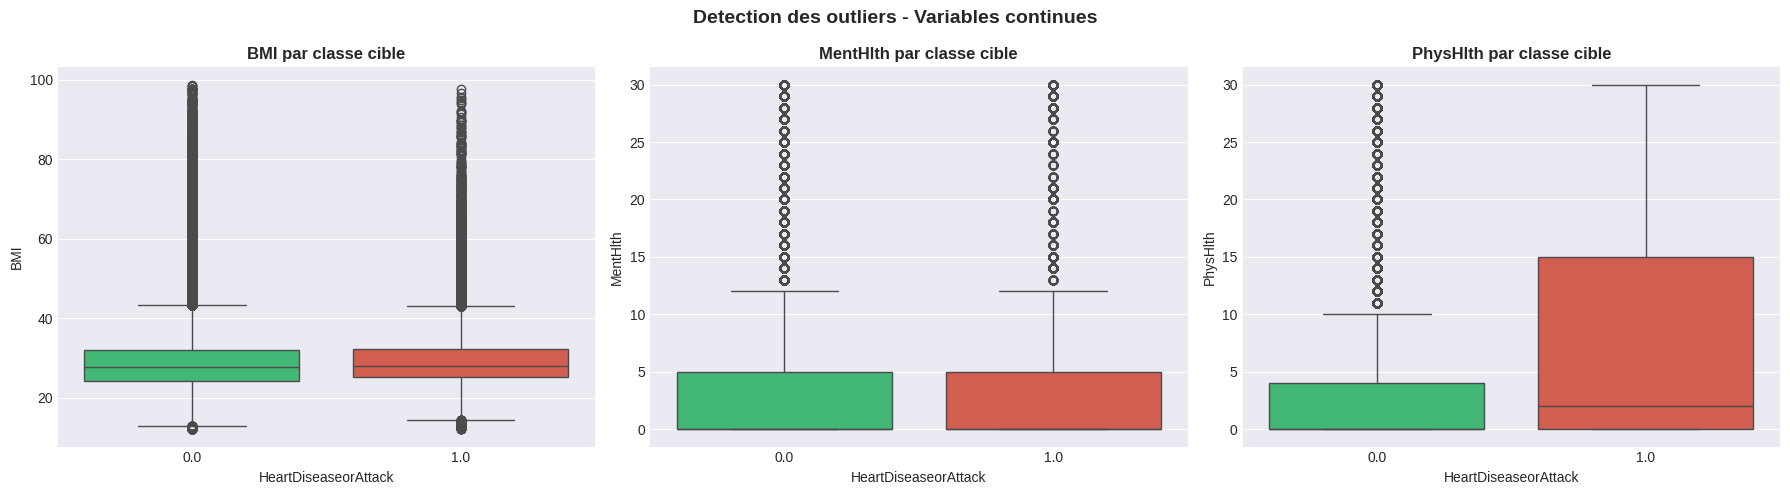

Figure sauvegardee : outliers_boxplots.png


In [163]:
# Detection des outliers (boxplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(continuous_cols):
    sns.boxplot(data=df_pd, y=col, x='HeartDiseaseorAttack',
                palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'{col} par classe cible', fontsize=12, fontweight='bold')

plt.suptitle('Detection des outliers - Variables continues', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardee : outliers_boxplots.png')

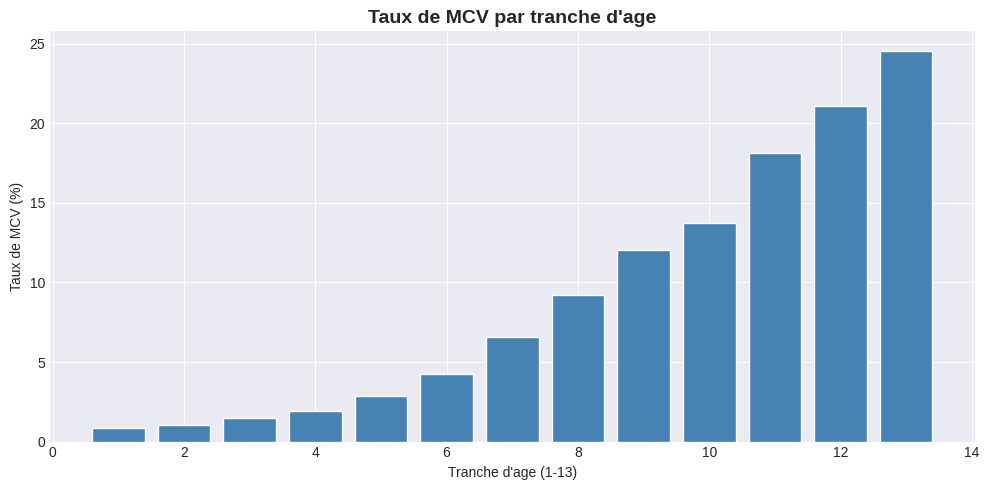

In [164]:
# Analyse par sous-groupes
age_analysis = df_pd.groupby('Age')['HeartDiseaseorAttack'].mean().reset_index()
age_analysis.columns = ['Age', 'Taux_MCV']

plt.figure(figsize=(10, 5))
plt.bar(age_analysis['Age'], age_analysis['Taux_MCV'] * 100, color='steelblue', edgecolor='white')
plt.title("Taux de MCV par tranche d'age", fontsize=14, fontweight='bold')
plt.xlabel("Tranche d'age (1-13)")
plt.ylabel('Taux de MCV (%)')
plt.tight_layout()
plt.savefig('/kaggle/working/mcv_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

In [165]:
# Normalisation des variables continues avec StandardScaler (Spark)
from pyspark.ml.feature import VectorAssembler, StandardScaler

# Assembler les colonnes continues en un vecteur
assembler_cont = VectorAssembler(inputCols=continuous_cols, outputCol='continuous_features')
df_assembled = assembler_cont.transform(df_spark)

# Appliquer StandardScaler
scaler = StandardScaler(inputCol='continuous_features', outputCol='scaled_continuous',
                        withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

print('Normalisation StandardScaler appliquee')
df_scaled.select('continuous_features', 'scaled_continuous').show(5, truncate=False)

Normalisation StandardScaler appliquee
+-------------------+-------------------------------------------------------------+
|continuous_features|scaled_continuous                                            |
+-------------------+-------------------------------------------------------------+
|[19.26,0.0,0.0]    |[-1.4326192617611693,-0.5685313924285554,-0.5378432578403006]|
|[39.46,30.0,6.0]   |[1.6115828854013199,2.846080417750633,0.1166461434254968]    |
|[43.4,0.0,0.0]     |[2.205353007174597,-0.5685313924285554,-0.5378432578403006]  |
|[21.95,2.0,3.0]    |[-1.0272279857281452,-0.3408906050832762,-0.2105985572074019]|
|[30.54,2.0,6.0]    |[0.26731144219887387,-0.3408906050832762,0.1166461434254968] |
+-------------------+-------------------------------------------------------------+
only showing top 5 rows


In [166]:
# Sauvegarder les donnees nettoyees et les artefacts EDA
df_spark.write.mode('overwrite').parquet('/kaggle/working/brfss_cleaned.parquet')
print('Donnees nettoyees sauvegardees : brfss_cleaned.parquet')

# Sauvegarder un echantillon Pandas pour le dashboard Streamlit (100K lignes)
df_sample = df_pd.sample(n=min(100000, len(df_pd)), random_state=42)
df_sample.to_csv('/kaggle/working/brfss_sample.csv', index=False)
print(f"Echantillon sauvegarde : brfss_sample.csv ({len(df_sample):,} lignes)")

# Sauvegarder les statistiques EDA
eda_stats = {
    'total_rows': int(df_spark.count()),
    'total_columns': len(df_spark.columns),
    'duplicates_removed': int(count_before - count_after),
    'positive_class_pct': float(df_pd['HeartDiseaseorAttack'].mean() * 100),
    'columns': list(df_spark.columns)
}

import json
with open('/kaggle/working/eda_stats.json', 'w') as f:
    json.dump(eda_stats, f, indent=2)
print('Statistiques EDA sauvegardees : eda_stats.json')

Donnees nettoyees sauvegardees : brfss_cleaned.parquet
Echantillon sauvegarde : brfss_sample.csv (100,000 lignes)
Statistiques EDA sauvegardees : eda_stats.json


## Resume du notebook 02

- Doublons supprimes
- Valeurs manquantes imputees (mediane / mode)
- EDA complete avec visualisations :
  - Distribution de la cible
  - Distributions univariees
  - Heatmap de correlation
  - Boxplots outliers
  - Taux MCV par age
- Normalisation StandardScaler appliquee
- Donnees nettoyees sauvegardees en Parquet
- Echantillon CSV pour Streamlit

**-> Passer au notebook 03 pour le Feature Engineering**